In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

# load data
df = pd.read_csv('temp_f1_data_20260215_022135.csv')

print(f"Loaded {len(df)} rows")
print(f"Dataset info:")
print(f" Years: {sorted(df['year'].unique())}")
print(f" Races: {df['race_name'].nunique()}")
print(f" Drivers: {df['driver_full_name'].nunique()}")
print(f" Teams: {df['constructor_name'].nunique()}")

# show first few rows
df.head(10)

Loaded 1359 rows
Dataset info:
 Years: [np.int64(2022), np.int64(2023), np.int64(2024)]
 Races: 25
 Drivers: 28
 Teams: 12


,year,round,race_name,circuit_id,circuit_name,country,date,driver_id,driver_number,driver_code,...,constructor_name,grid_position,finish_position,position_text,points,laps_completed,status,time,finished,dnf
0,2022,1,Bahrain Grand Prix,bahrain,Bahrain International Circuit,Bahrain,2022-03-20,leclerc,16,LEC,...,Ferrari,1,1,1,26.0,57,Finished,1:37:33.584,True,False
1,2022,1,Bahrain Grand Prix,bahrain,Bahrain International Circuit,Bahrain,2022-03-20,sainz,55,SAI,...,Ferrari,3,2,2,18.0,57,Finished,+5.598,True,False
2,2022,1,Bahrain Grand Prix,bahrain,Bahrain International Circuit,Bahrain,2022-03-20,hamilton,44,HAM,...,Mercedes,5,3,3,15.0,57,Finished,+9.675,True,False
3,2022,1,Bahrain Grand Prix,bahrain,Bahrain International Circuit,Bahrain,2022-03-20,russell,63,RUS,...,Mercedes,9,4,4,12.0,57,Finished,+11.211,True,False
4,2022,1,Bahrain Grand Prix,bahrain,Bahrain International Circuit,Bahrain,2022-03-20,kevin_magnussen,20,MAG,...,Haas F1 Team,7,5,5,10.0,57,Finished,+14.754,True,False
5,2022,1,Bahrain Grand Prix,bahrain,Bahrain International Circuit,Bahrain,2022-03-20,bottas,77,BOT,...,Alfa Romeo,6,6,6,8.0,57,Finished,+16.119,True,False
6,2022,1,Bahrain Grand Prix,bahrain,Bahrain International Circuit,Bahrain,2022-03-20,ocon,31,OCO,...,Alpine F1 Team,11,7,7,6.0,57,Finished,+19.423,True,False
7,2022,1,Bahrain Grand Prix,bahrain,Bahrain International Circuit,Bahrain,2022-03-20,tsunoda,22,TSU,...,AlphaTauri,16,8,8,4.0,57,Finished,+20.386,True,False
8,2022,1,Bahrain Grand Prix,bahrain,Bahrain International Circuit,Bahrain,2022-03-20,alonso,14,ALO,...,Alpine F1 Team,8,9,9,2.0,57,Finished,+22.390,True,False
9,2022,1,Bahrain Grand Prix,bahrain,Bahrain International Circuit,Bahrain,2022-03-20,zhou,24,ZHO,...,Alfa Romeo,15,10,10,1.0,57,Finished,+23.064,True,False


In [3]:
# check for missing values
print("Missing values")
print(df.isnull().sum())

# check data types
print("\nData types:")
print(df.dtypes)

# basic stats
print("\nNumerical columns summary:")
df.describe()

Missing values
year                  0
round                 0
race_name             0
circuit_id            0
circuit_name          0
country               0
date                  0
driver_id             0
driver_number         0
driver_code           0
driver_forename       0
driver_surname        0
driver_full_name      0
constructor_id        0
constructor_name      0
grid_position         0
finish_position       0
position_text         0
points                0
laps_completed        0
status                0
time                260
finished              0
dnf                   0
dtype: int64

Data types:
year                  int64
round                 int64
race_name               str
circuit_id              str
circuit_name            str
country                 str
date                    str
driver_id               str
driver_number         int64
driver_code             str
driver_forename         str
driver_surname          str
driver_full_name        str
constructor_id     

,year,round,driver_number,grid_position,finish_position,points,laps_completed
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.00000,1359.000000,1359.000000
mean,2023.028698,11.859455,27.238411,10.293598,10.49301,5.097130,54.789551
std,0.822135,6.571918,22.708059,5.796618,5.76476,7.245494,16.603312
min,2022.000000,1.000000,1.000000,0.000000,1.00000,0.000000,0.000000
25%,2022.000000,6.000000,11.000000,5.000000,5.50000,0.000000,51.000000
50%,2023.000000,12.000000,22.000000,10.000000,10.00000,1.000000,57.000000
75%,2024.000000,17.500000,44.000000,15.000000,15.00000,9.500000,69.000000
max,2024.000000,24.000000,81.000000,20.000000,20.00000,26.000000,78.000000


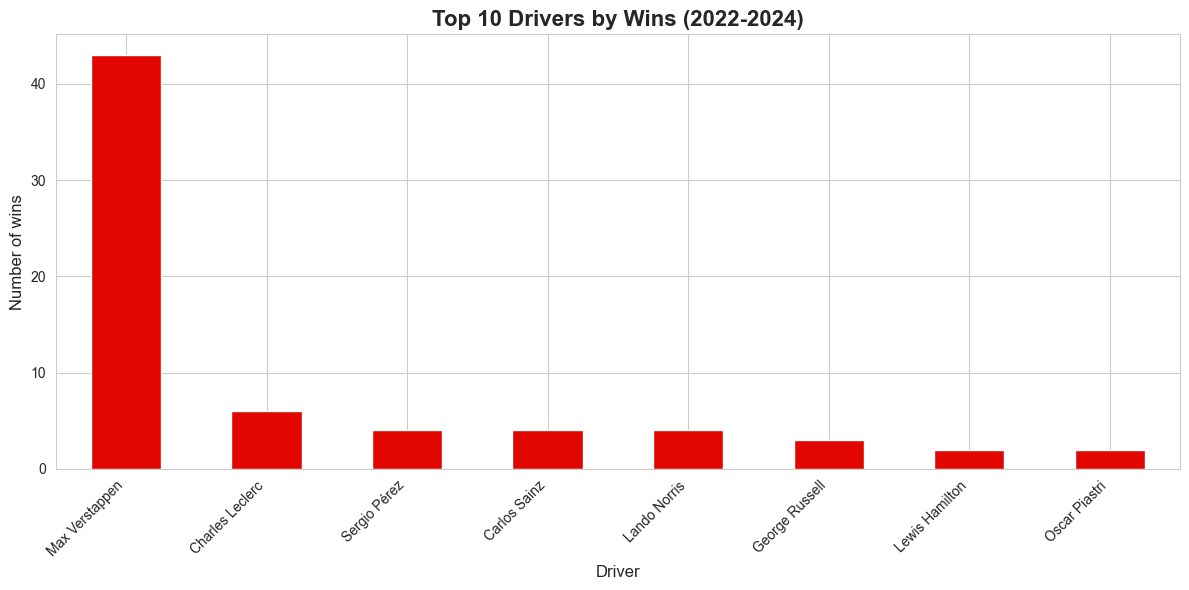

Most successful drivers:
 Max Verstappen: 43 wins
 Charles Leclerc: 6 wins
 Sergio Pérez: 4 wins
 Carlos Sainz: 4 wins
 Lando Norris: 4 wins
 George Russell: 3 wins
 Lewis Hamilton: 2 wins
 Oscar Piastri: 2 wins


In [4]:
# drivers with most wins
winners = df[df['finish_position'] == 1]
win_counts = winners['driver_full_name'].value_counts().head(10)

plt.figure(figsize=(12,6))
win_counts.plot(kind='bar', color='#E10600')
plt.title('Top 10 Drivers by Wins (2022-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Driver', fontsize=12)
plt.ylabel('Number of wins', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('driver_wins.png', dpi=300, bbox_inches='tight')
plt.show()

print("Most successful drivers:")
for driver, wins in win_counts.items():
    print(f" {driver}: {wins} wins")

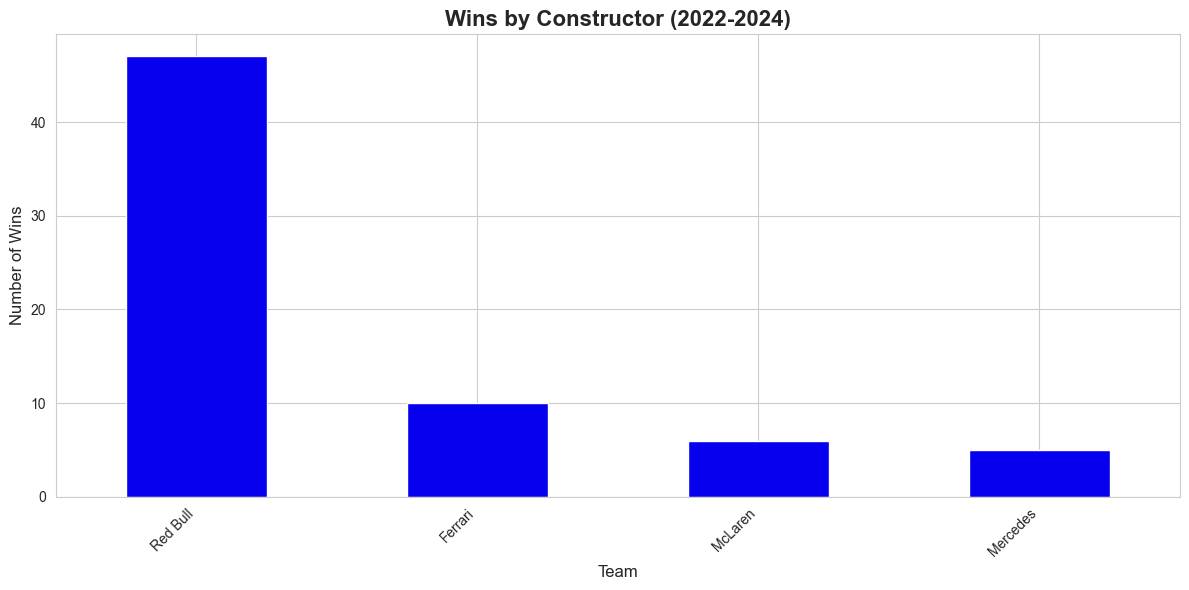

Team performance:
constructor_name
Red Bull    47
Ferrari     10
McLaren      6
Mercedes     5
Name: count, dtype: int64


In [5]:
# teams with most wins
team_wins = winners['constructor_name'].value_counts()

plt.figure(figsize=(12,6))
team_wins.plot(kind='bar', color='#0600EF')
plt.title('Wins by Constructor (2022-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Team', fontsize=12)
plt.ylabel('Number of Wins', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('team_wins.png', dpi=300, bbox_inches='tight')
plt.show()

print("Team performance:")
print(team_wins)

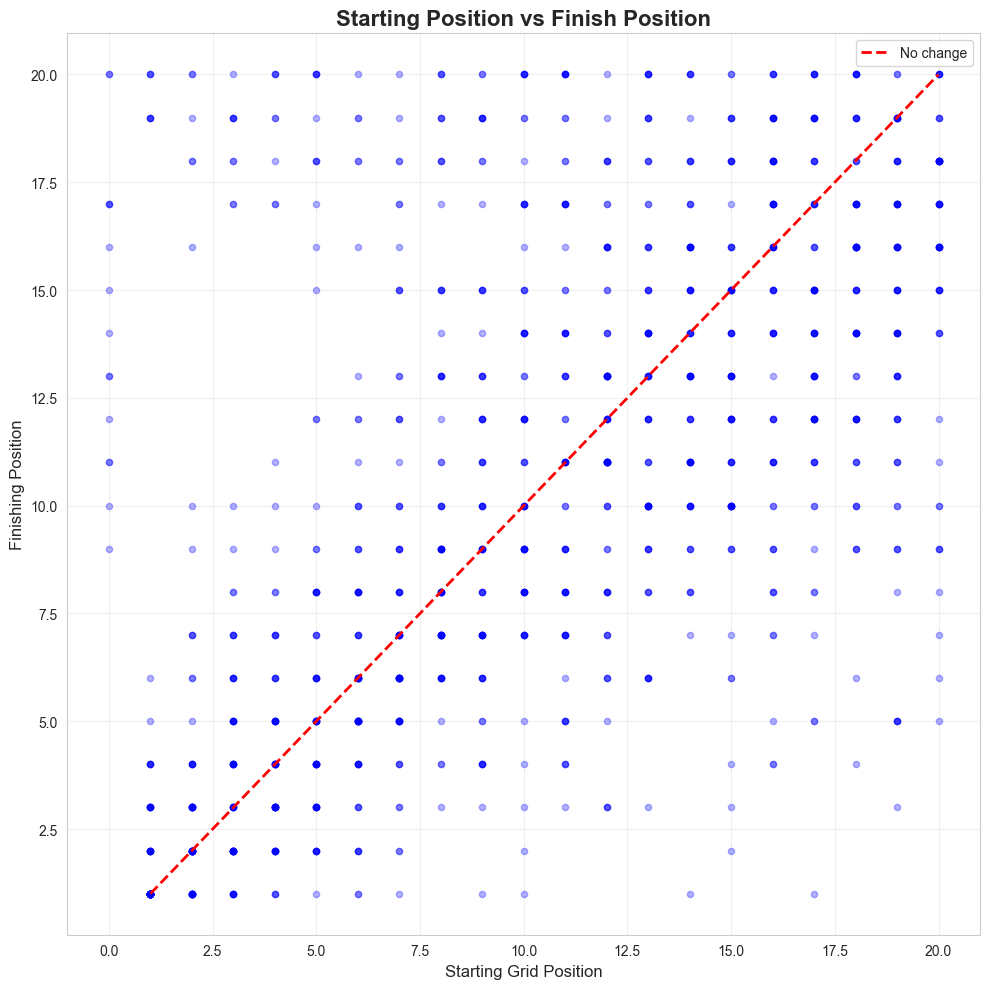


Pole position win rate: 51.5%
 Pole positions: 68
 Pole wins: 35


In [6]:
# grid position vs finish position
finished_races = df[df['finish_position'] <= 20]  # Exclude DNFs

plt.figure(figsize=(10, 10))
plt.scatter(finished_races['grid_position'], 
            finished_races['finish_position'], 
            alpha=0.3, s=20, c='blue')
plt.plot([1, 20], [1, 20], 'r--', linewidth=2, label='No change')
plt.xlabel('Starting Grid Position', fontsize=12)
plt.ylabel('Finishing Position', fontsize=12)
plt.title('Starting Position vs Finish Position', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('grid_vs_finish.png', dpi=300, bbox_inches='tight')
plt.show()

# how often does pole position win?
pole_positions = df[df['grid_position'] == 1]
pole_wins = pole_positions[pole_positions['finish_position'] == 1]
pole_win_rate = (len(pole_wins) / len(pole_positions)) * 100

print(f"\nPole position win rate: {pole_win_rate:.1f}%")
print(f" Pole positions: {len(pole_positions)}")
print(f" Pole wins: {len(pole_wins)}")

In [7]:
# What features might predict race winners?

print("Potential ML features to create:\n")

# 1. Driver historical performance
print("1. Driver Win Rate")
driver_races = df.groupby('driver_full_name').size()
driver_wins = winners.groupby('driver_full_name').size()
driver_win_rate = (driver_wins / driver_races * 100).sort_values(ascending=False)
print(driver_win_rate.head())

# 2. Team performance
print("\n2. Team Average Finish Position")
team_avg_finish = df.groupby('constructor_name')['finish_position'].mean().sort_values()
print(team_avg_finish.head())

# 3. Circuit-specific performance
print("\n3. Circuit Difficulty (average finishing position)")
circuit_difficulty = df.groupby('race_name')['finish_position'].std().sort_values(ascending=False)
print("Most unpredictable races:")
print(circuit_difficulty.head())

# 4. Recent form (last 3 races)
print("\n4. Driver Recent Form (last 3 races avg position)")
df_sorted = df.sort_values(['driver_full_name', 'year', 'round'])
df_sorted['recent_form'] = df_sorted.groupby('driver_full_name')['finish_position'].rolling(3).mean().reset_index(0, drop=True)
print(df_sorted[['driver_full_name', 'race_name', 'finish_position', 'recent_form']].tail(10))


Potential ML features to create:

1. Driver Win Rate
driver_full_name
Max Verstappen     63.235294
Charles Leclerc     8.823529
Carlos Sainz        5.970149
Lando Norris        5.882353
Sergio Pérez        5.882353
dtype: float64

2. Team Average Finish Position
constructor_name
Red Bull         4.933824
Mercedes         6.514706
Ferrari          6.522059
McLaren          8.161765
Aston Martin    10.882353
Name: finish_position, dtype: float64

3. Circuit Difficulty (average finishing position)
Most unpredictable races:
race_name
Chinese Grand Prix           5.91608
French Grand Prix            5.91608
Qatar Grand Prix             5.83974
Emilia Romagna Grand Prix    5.83974
Las Vegas Grand Prix         5.83974
Name: finish_position, dtype: float64

4. Driver Recent Form (last 3 races avg position)
     driver_full_name                 race_name  finish_position  recent_form
1175     Yuki Tsunoda          Dutch Grand Prix               17    14.000000
1198     Yuki Tsunoda        Itali

In [8]:
# summary of insights
insights = {
    'total_races': df['race_name'].nunique(),
    'total_drivers': df['driver_full_name'].nunique(),
    'total_teams': df['constructor_name'].nunique(),
    'pole_win_rate': pole_win_rate,
    'most_wins_driver': win_counts.index[0],
    'most_wins_count': win_counts.values[0],
    'most_wins_team': team_wins.index[0],
}

print("\nKey insights:")
for key, value in insights.items():
    print(f"  {key}: {value}")


Key insights:
  total_races: 25
  total_drivers: 28
  total_teams: 12
  pole_win_rate: 51.470588235294116
  most_wins_driver: Max Verstappen
  most_wins_count: 43
  most_wins_team: Red Bull
